In [1]:
# 1. Load all symbolic outputs and validate dataset integrity
from pathlib import Path
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-ntsa-symbolic")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
DURATIONS = [60, 120, 180]
STATES = ["Awake", "Drowsy"]
METRICS = ["pct_0v", "pct_1v", "pct_2v"]
PRIMARY_METRICS = ["pct_0v", "pct_1v", "pct_2v"]
METRIC_LABELS = {m: m.replace("pct_", "").upper() for m in METRICS}
RNG_SEED = 20260827
N_BOOTSTRAP = 20_000

candidates = [
    Path("../results/symbolic/processed"),
    Path("phase1/results/symbolic/processed"),
    Path("results/symbolic/processed"),
]
DATA_DIR = next((p.resolve() for p in candidates if p.is_dir()), None)
if DATA_DIR is None:
    raise FileNotFoundError("Cannot locate results/symbolic/processed from the current working directory.")
files = sorted(DATA_DIR.glob("session_*_symbolic_analysis.csv"))
if not files:
    raise FileNotFoundError(f"No session symbolic CSV files found in {DATA_DIR}")
df = pd.concat((pd.read_csv(path) for path in files), ignore_index=True)

# The frozen export uses abrupt_gt_20pct; expose the protocol's analysis alias.
if "abrupt_change_pct" not in df and "abrupt_gt_20pct" in df:
    df["abrupt_change_pct"] = df["abrupt_gt_20pct"]
required_columns = [
    "session", "state", "window_size_s", "window_id", "analysis_included",
    "stationarity_pass_processed", "n_intervals", "n_words", "abrupt_change_pct",
    "pct_0v", "pct_1v", "pct_2v",
]
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise KeyError(f"Missing required columns: {missing_columns}")

df["window_size_s"] = pd.to_numeric(df["window_size_s"], errors="raise").astype(int)
included_mask = df["analysis_included"].fillna(False).astype(bool)
overview = pd.DataFrame({
    "item": ["CSV files", "sessions", "rows", "included rows", "excluded rows"],
    "value": [len(files), df["session"].nunique(), len(df), int(included_mask.sum()), int((~included_mask).sum())],
})
rows_by_duration = df.groupby("window_size_s", observed=True).size().rename("n_rows").reset_index()
rows_by_state = df.groupby("state", observed=True).size().rename("n_rows").reset_index()
rows_by_session = df.groupby("session", observed=True).size().rename("n_rows").reset_index()
missing_required = df[required_columns].isna().sum().rename("n_missing").reset_index(name="n_missing").rename(columns={"index": "column"})

assert len(files) == 20, f"Expected 20 session CSVs, found {len(files)}"
assert df["session"].nunique() == 20, f"Expected 20 sessions, found {df['session'].nunique()}"
assert set(DURATIONS).issubset(df["window_size_s"].unique()), "One or more target durations are absent."
assert set(STATES).issubset(df["state"].dropna().unique()), "Awake or Drowsy state is absent."
assert np.isfinite(df.loc[included_mask, METRICS].to_numpy(dtype=float)).all(), "Non-finite symbolic metric in included windows."

print(f"Data directory: {DATA_DIR}")
display(overview, rows_by_duration, rows_by_state, rows_by_session, missing_required)

Data directory: /home/vutu0809/Desktop/NTSA_Foundation/phase1/results/symbolic/processed


,item,value
0,CSV files,20
1,sessions,20
2,rows,1544
3,included rows,1541
4,excluded rows,3


,window_size_s,n_rows
0,60,901
1,120,405
2,180,238


,state,n_rows
0,Awake,1026
1,Drowsy,518


,session,n_rows
0,session_01,50
1,session_04,79
2,session_05,83
3,session_06,82
4,session_07,79
5,session_08,80
6,session_09,111
7,session_10,61
8,session_11,66
9,session_12,94


,column,n_missing
0,session,0
1,state,0
2,window_size_s,0
3,window_id,0
4,analysis_included,0
5,stationarity_pass_processed,0
6,n_intervals,0
7,n_words,3
8,abrupt_change_pct,0
9,pct_0v,3


In [2]:
# 2. Validate symbolic invariants for every included window
included = df.loc[included_mask].copy()
invariant_checks = {
    "0V + 1V + 2V = 100": np.isclose(
        included[["pct_0v", "pct_1v", "pct_2v"]].sum(axis=1), 100.0, atol=1e-6
    ),
    "n_words = n_intervals - 2": included["n_words"].eq(included["n_intervals"] - 2),
}
invariant_results = pd.DataFrame([
    {"test": name, "n_pass": int(check.sum()), "n_fail": int((~check).sum())}
    for name, check in invariant_checks.items()
])
assert invariant_results["n_fail"].eq(0).all(), "At least one symbolic invariant failed."
display(invariant_results)

,test,n_pass,n_fail
0,0V + 1V + 2V = 100,1541,0
1,n_words = n_intervals - 2,1541,0


,window_size_s,state,n_windows,analysis_included_pct,stationarity_pass_pct,median_n_intervals,median_abrupt_change_pct
0,60,Awake,596,100.000,100.0,81.0,0.000
1,60,Drowsy,305,100.000,100.0,86.0,0.000
2,120,Awake,269,100.000,100.0,162.0,0.588
3,120,Drowsy,136,99.265,100.0,174.0,0.649
4,180,Awake,161,99.379,100.0,244.0,0.816
5,180,Drowsy,77,98.701,100.0,263.0,0.714


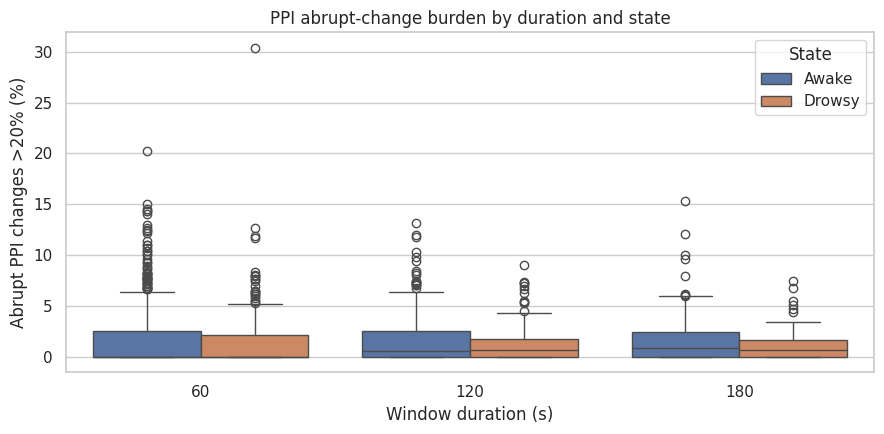

In [3]:
# 3. Compare analysis eligibility and PPI/QC indicators by duration and state
qc_summary = (
    df.groupby(["window_size_s", "state"], observed=True)
      .agg(
          n_windows=("window_id", "size"),
          analysis_included_pct=("analysis_included", lambda x: 100 * x.fillna(False).astype(bool).mean()),
          stationarity_pass_pct=("stationarity_pass_processed", lambda x: 100 * x.fillna(False).astype(bool).mean()),
          median_n_intervals=("n_intervals", "median"),
          median_abrupt_change_pct=("abrupt_change_pct", "median"),
      ).reset_index().sort_values(["window_size_s", "state"])
)
display(qc_summary.round(3))

plt.figure(figsize=(9, 4.5))
sns.boxplot(data=df, x="window_size_s", y="abrupt_change_pct", hue="state", hue_order=STATES)
plt.xlabel("Window duration (s)")
plt.ylabel("Abrupt PPI changes >20% (%)")
plt.title("PPI abrupt-change burden by duration and state")
plt.legend(title="State")
plt.tight_layout()
plt.show()

,window_size_s,state,metric,n_windows,median,q1,q3,IQR
0,60,Awake,0V,596,22.222,15.104,35.359,20.255
1,60,Awake,1V,596,41.841,35.327,46.974,11.647
2,60,Awake,2V,596,32.413,22.892,40.301,17.410
3,60,Drowsy,0V,305,25.000,18.182,35.484,17.302
4,60,Drowsy,1V,305,42.391,36.471,46.341,9.871
5,60,Drowsy,2V,305,31.111,21.739,37.079,15.340
6,120,Awake,0V,269,27.717,19.048,51.724,32.677
7,120,Awake,1V,269,41.096,33.103,44.920,11.816
8,120,Awake,2V,269,27.950,14.124,36.667,22.542
9,120,Drowsy,0V,135,29.586,21.961,51.076,29.114


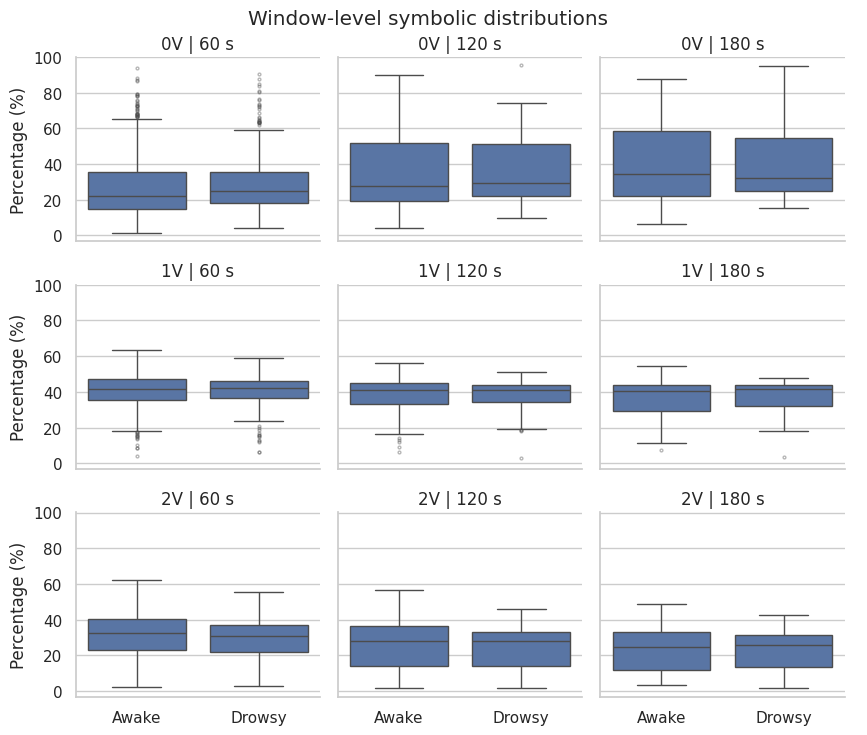

In [4]:
# 4. Describe the window-level symbolic landscape (no window-level inference)
window_long = included.melt(
    id_vars=["window_size_s", "state", "session"], value_vars=METRICS,
    var_name="metric", value_name="percentage",
)
window_long["metric"] = window_long["metric"].map(METRIC_LABELS)
window_long["metric"] = pd.Categorical(
    window_long["metric"], [METRIC_LABELS[m] for m in METRICS], ordered=True
)
window_summary = (
    window_long.groupby(["window_size_s", "state", "metric"], observed=True)["percentage"]
    .agg(n_windows="size", median="median", q1=lambda x: x.quantile(.25), q3=lambda x: x.quantile(.75))
    .reset_index()
)
window_summary["IQR"] = window_summary["q3"] - window_summary["q1"]
display(window_summary[["window_size_s", "state", "metric", "n_windows", "median", "q1", "q3", "IQR"]].round(3))

g = sns.catplot(
    data=window_long, x="state", y="percentage", row="metric", col="window_size_s",
    kind="box", order=STATES, sharey=True, height=2.5, aspect=1.15,
    flierprops={"markersize": 2, "alpha": .4},
)
g.set_axis_labels("", "Percentage (%)")
g.set_titles(row_template="{row_name}", col_template="{col_name} s")
g.figure.suptitle("Window-level symbolic distributions", y=1.01)
plt.show()

In [5]:
# 5. Aggregate valid windows to the session × duration × state inference unit
aggregation_spec = {f"{m}_median": (m, "median") for m in METRICS}
session_state = (
    included.groupby(["session", "window_size_s", "state"], observed=True)
    .agg(**aggregation_spec, n_valid_windows=("window_id", "size"))
    .reset_index()
)
session_metric = session_state.melt(
    id_vars=["session", "window_size_s", "state", "n_valid_windows"],
    value_vars=list(aggregation_spec), var_name="metric", value_name="session_median",
)
session_metric["metric"] = session_metric["metric"].str.replace("_median$", "", regex=True)
values_wide = session_metric.pivot(
    index=["session", "window_size_s", "metric"], columns="state", values="session_median"
)
counts_wide = session_state.pivot(
    index=["session", "window_size_s"], columns="state", values="n_valid_windows"
).rename(columns={"Awake": "Awake_n_windows", "Drowsy": "Drowsy_n_windows"})
paired_df = values_wide.join(counts_wide, on=["session", "window_size_s"]).reset_index()
paired_df = paired_df.dropna(subset=STATES).copy()
paired_df["Delta"] = paired_df["Drowsy"] - paired_df["Awake"]
paired_df["metric_label"] = paired_df["metric"].map(METRIC_LABELS)
pair_counts = (
    paired_df.groupby(["window_size_s", "metric_label"], observed=True)["session"]
    .nunique().rename("n_eligible_session_pairs").reset_index()
)
preview_cols = [
    "session", "window_size_s", "metric_label", "Awake", "Drowsy", "Delta",
    "Awake_n_windows", "Drowsy_n_windows",
]
display(
    paired_df[preview_cols].sort_values(["session", "window_size_s", "metric_label"]).head(15).round(3),
    pair_counts,
)

state,session,window_size_s,metric_label,Awake,Drowsy,Delta,Awake_n_windows,Drowsy_n_windows
0,session_01,60,0V,18.563,25.641,7.078,24,7
1,session_01,60,1V,46.104,44.872,-1.232,24,7
2,session_01,60,2V,35.632,29.487,-6.144,24,7
3,session_01,120,0V,34.615,42.857,8.242,11,1
4,session_01,120,1V,42.949,36.646,-6.303,11,1
5,session_01,120,2V,22.436,20.497,-1.939,11,1
6,session_01,180,0V,25.207,40.408,15.202,6,1
7,session_01,180,1V,49.274,40.000,-9.274,6,1
8,session_01,180,2V,24.632,19.592,-5.040,6,1
9,session_04,60,0V,28.947,25.610,-3.338,29,17


,window_size_s,metric_label,n_eligible_session_pairs
0,60,0V,20
1,60,1V,20
2,60,2V,20
3,120,0V,20
4,120,1V,20
5,120,2V,20
6,180,0V,20
7,180,1V,20
8,180,2V,20


,window_size_s,metric_label,n_sessions,median_delta,q1_delta,q3_delta,IQR_delta,n_delta_positive,n_delta_negative,n_delta_zero,direction_consistency_pct
0,60,0V,20.0,4.044,-0.290,7.402,7.692,14.0,6.0,0.0,70.0
1,60,1V,20.0,0.408,-1.720,2.390,4.110,10.0,10.0,0.0,50.0
2,60,2V,20.0,-0.905,-6.669,0.556,7.224,7.0,13.0,0.0,65.0
3,120,0V,20.0,2.319,-5.086,6.456,11.542,13.0,7.0,0.0,65.0
4,120,1V,20.0,0.027,-2.422,2.631,5.053,10.0,10.0,0.0,50.0
5,120,2V,20.0,-2.297,-4.844,2.003,6.847,8.0,12.0,0.0,60.0
6,180,0V,20.0,4.583,-1.433,15.228,16.661,13.0,7.0,0.0,65.0
7,180,1V,20.0,-0.056,-4.425,3.513,7.938,10.0,10.0,0.0,50.0
8,180,2V,20.0,-2.673,-5.800,-0.207,5.593,5.0,15.0,0.0,75.0


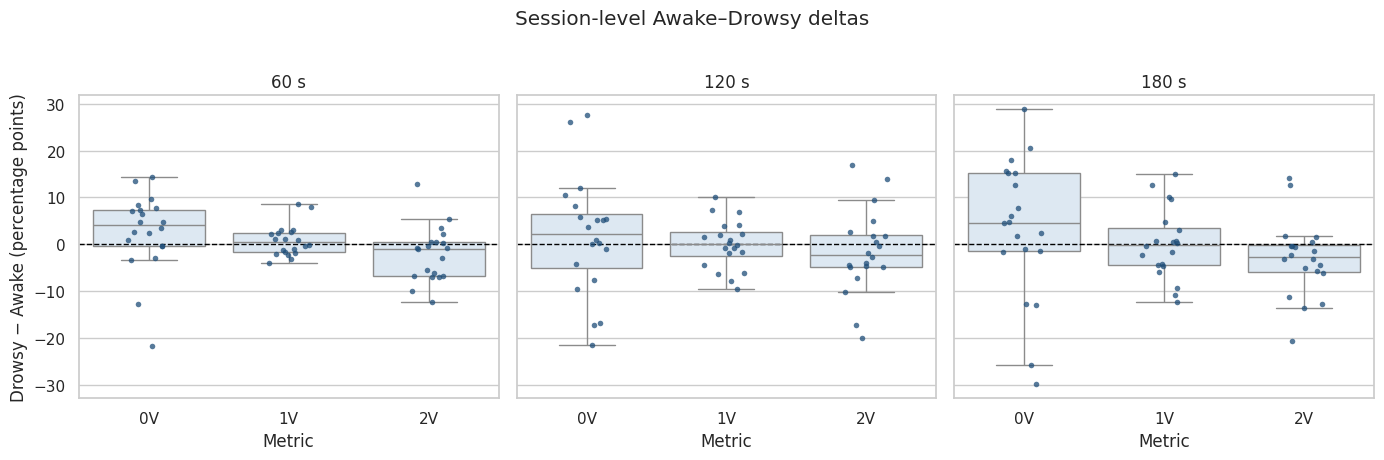

In [6]:
# 6. Quantify cross-session direction consistency
def direction_summary(group):
    delta = group["Delta"].dropna().to_numpy(float)
    n_pos, n_neg, n_zero = (int((delta > 0).sum()), int((delta < 0).sum()), int((delta == 0).sum()))
    nonzero = n_pos + n_neg
    return pd.Series({
        "n_sessions": len(delta),
        "median_delta": np.median(delta),
        "q1_delta": np.quantile(delta, .25),
        "q3_delta": np.quantile(delta, .75),
        "IQR_delta": np.quantile(delta, .75) - np.quantile(delta, .25),
        "n_delta_positive": n_pos,
        "n_delta_negative": n_neg,
        "n_delta_zero": n_zero,
        "direction_consistency_pct": 100 * max(n_pos, n_neg) / nonzero if nonzero else 100.0,
    })

direction_results = (
    paired_df.groupby(["window_size_s", "metric_label"], observed=True)
    .apply(direction_summary, include_groups=False).reset_index()
    .sort_values(["window_size_s", "metric_label"])
)
display(direction_results.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, duration in zip(axes, DURATIONS):
    plot_data = paired_df[paired_df["window_size_s"].eq(duration)]
    sns.boxplot(
        data=plot_data, x="metric_label", y="Delta", order=[METRIC_LABELS[m] for m in METRICS],
        ax=ax, color="#d9e8f5", showfliers=False,
    )
    sns.stripplot(
        data=plot_data, x="metric_label", y="Delta", order=[METRIC_LABELS[m] for m in METRICS],
        ax=ax, color="#1f4e79", jitter=.16, size=4, alpha=.75,
    )
    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set(
        title=f"{duration} s", xlabel="Metric",
        ylabel="Drowsy − Awake (percentage points)" if duration == 60 else "",
    )
fig.suptitle("Session-level Awake–Drowsy deltas", y=1.02)
fig.tight_layout()
plt.show()

,duration_s,metric,n_sessions,median_awake,median_drowsy,median_delta,CI_low,CI_high,p,rank_biserial_r,q_BH
0,60,0V,20,22.8870,24.6880,4.0435,0.3524,7.1843,0.0532,0.4952,0.2276
1,60,1V,20,42.4713,43.4062,0.4083,-1.4683,2.2269,0.4980,0.1810,0.6403
2,60,2V,20,33.1545,30.5979,-0.9055,-6.4032,0.3713,0.0759,-0.4571,0.2276
3,120,0V,20,27.4032,27.6446,2.3188,-2.6355,5.6327,0.4749,0.1905,0.6403
4,120,1V,20,41.8424,41.9387,0.0275,-1.6658,2.1276,0.9273,0.0286,0.9563
5,120,2V,20,30.3419,28.1777,-2.2975,-4.6842,1.7849,0.3300,-0.2571,0.5940
6,180,0V,20,29.0849,38.3672,4.5834,-1.1178,13.9440,0.1650,0.3619,0.3712
7,180,1V,20,41.1018,40.7478,-0.0555,-4.3145,1.9453,0.9563,-0.0190,0.9563
8,180,2V,20,27.2993,23.2500,-2.6727,-5.3657,-0.4385,0.0484,-0.5048,0.2276


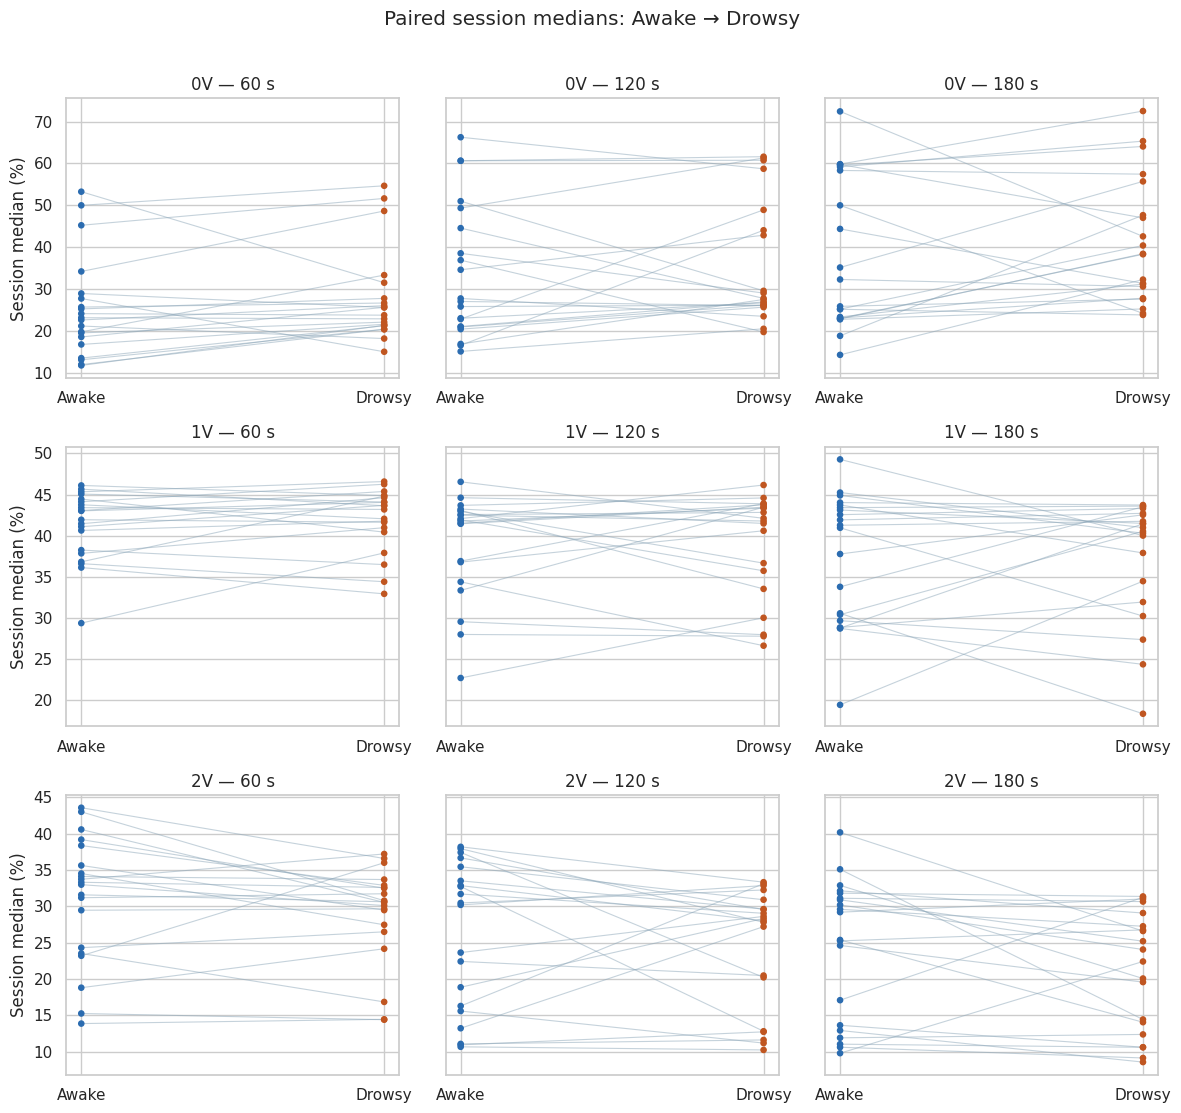

In [7]:
# 7. Primary session-level Awake–Drowsy inference
def bootstrap_median_ci(values, seed, n_bootstrap=N_BOOTSTRAP):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    sampled = values[rng.integers(0, values.size, size=(n_bootstrap, values.size))]
    return tuple(np.quantile(np.median(sampled, axis=1), [.025, .975]))

def rank_biserial_paired(values):
    values = np.asarray(values, dtype=float)
    values = values[values != 0]
    if values.size == 0:
        return 0.0
    ranks = stats.rankdata(np.abs(values))
    w_plus, w_minus = ranks[values > 0].sum(), ranks[values < 0].sum()
    return float((w_plus - w_minus) / (w_plus + w_minus))

def bh_adjust(p_values):
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted = np.minimum.accumulate((ranked * len(p) / np.arange(1, len(p) + 1))[::-1])[::-1]
    out = np.empty_like(adjusted)
    out[order] = np.clip(adjusted, 0, 1)
    return out

def paired_inference_table(source, metrics, seed_offset=0):
    records = []
    for i, (duration, metric) in enumerate((d, m) for d in DURATIONS for m in metrics):
        group = source[source["window_size_s"].eq(duration) & source["metric"].eq(metric)].dropna(subset=STATES)
        delta = group["Delta"].to_numpy(float)
        ci_low, ci_high = bootstrap_median_ci(delta, RNG_SEED + seed_offset + i)
        p_value = 1.0 if np.all(delta == 0) else stats.wilcoxon(
            delta, alternative="two-sided", zero_method="wilcox"
        ).pvalue
        records.append({
            "duration_s": duration,
            "metric": METRIC_LABELS[metric],
            "n_sessions": len(delta),
            "median_awake": group["Awake"].median(),
            "median_drowsy": group["Drowsy"].median(),
            "median_delta": np.median(delta),
            "CI_low": ci_low,
            "CI_high": ci_high,
            "p": p_value,
            "rank_biserial_r": rank_biserial_paired(delta),
        })
    result = pd.DataFrame(records)
    result["q_BH"] = bh_adjust(result["p"])
    return result

primary_results = paired_inference_table(paired_df, PRIMARY_METRICS)
display(primary_results.round(4))

fig, axes = plt.subplots(3, 3, figsize=(12, 11), sharey="row")
for row, metric in enumerate(PRIMARY_METRICS):
    for col, duration in enumerate(DURATIONS):
        ax = axes[row, col]
        group = paired_df[paired_df["metric"].eq(metric) & paired_df["window_size_s"].eq(duration)]
        for _, item in group.iterrows():
            ax.plot([0, 1], [item["Awake"], item["Drowsy"]], color="#8ca6b8", alpha=.5, linewidth=.8)
            ax.scatter([0, 1], [item["Awake"], item["Drowsy"]], color=["#2b6cb0", "#c05621"], s=14, zorder=3)
        ax.set_xticks([0, 1], STATES)
        ax.set_title(f"{METRIC_LABELS[metric]} — {duration} s")
        ax.set_ylabel("Session median (%)" if col == 0 else "")
fig.suptitle("Paired session medians: Awake → Drowsy", y=1.01)
fig.tight_layout()
plt.show()

,metric,n_sessions_all_durations,rho_60_180,p_60_180,sign_agreement_60_180_pct,rho_120_180,p_120_180,sign_agreement_120_180_pct
0,0V,20,0.6857,0.0008,85.0,0.8030,0.0000,90.0
1,1V,20,0.5970,0.0055,70.0,0.6075,0.0045,60.0
2,2V,20,0.7023,0.0006,80.0,0.7549,0.0001,75.0


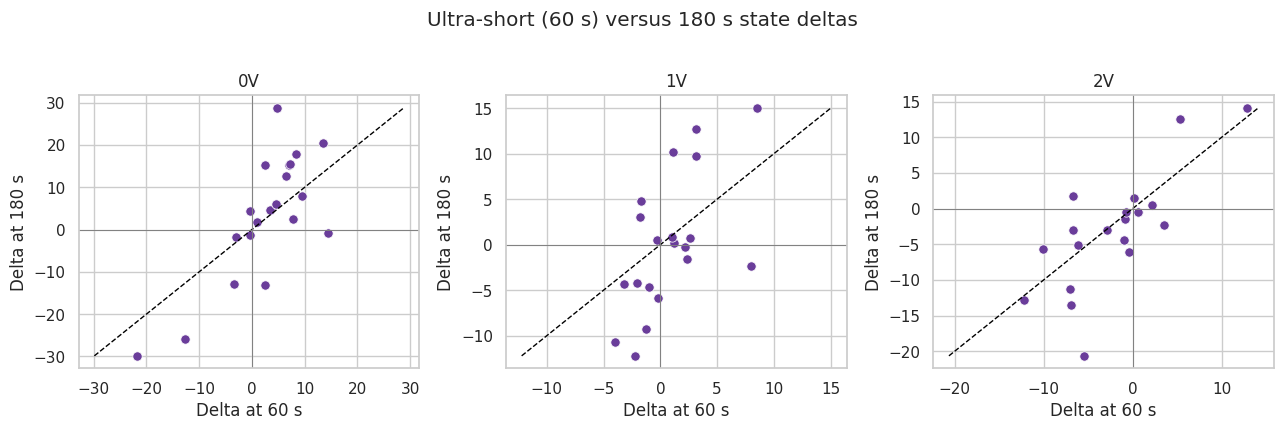

In [8]:
# 8. Test duration robustness of session-level primary-metric deltas
robustness_records = []
delta_wide_by_metric = {}
for metric in PRIMARY_METRICS:
    wide = paired_df[paired_df["metric"].eq(metric)].pivot(index="session", columns="window_size_s", values="Delta")
    wide = wide.reindex(columns=DURATIONS)
    delta_wide_by_metric[metric] = wide
    complete = wide.dropna(subset=DURATIONS)
    rho_60, p_60 = stats.spearmanr(complete[60], complete[180])
    rho_120, p_120 = stats.spearmanr(complete[120], complete[180])
    robustness_records.append({
        "metric": METRIC_LABELS[metric],
        "n_sessions_all_durations": len(complete),
        "rho_60_180": rho_60,
        "p_60_180": p_60,
        "sign_agreement_60_180_pct": 100 * (np.sign(complete[60]) == np.sign(complete[180])).mean(),
        "rho_120_180": rho_120,
        "p_120_180": p_120,
        "sign_agreement_120_180_pct": 100 * (np.sign(complete[120]) == np.sign(complete[180])).mean(),
    })
robustness_results = pd.DataFrame(robustness_records)
display(robustness_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, metric in zip(axes, PRIMARY_METRICS):
    complete = delta_wide_by_metric[metric].dropna(subset=DURATIONS)
    sns.scatterplot(x=complete[60], y=complete[180], ax=ax, color="#6a3d9a", s=45)
    lower = min(complete[60].min(), complete[180].min())
    upper = max(complete[60].max(), complete[180].max())
    ax.plot([lower, upper], [lower, upper], "--", color="black", linewidth=1)
    ax.axhline(0, color="grey", linewidth=.7)
    ax.axvline(0, color="grey", linewidth=.7)
    ax.set(title=METRIC_LABELS[metric], xlabel="Delta at 60 s", ylabel="Delta at 180 s")
fig.suptitle("Ultra-short (60 s) versus 180 s state deltas", y=1.02)
fig.tight_layout()
plt.show()

In [9]:
# 9. Assess sensitivity to stationarity filtering
def build_paired_from_windows(windows, metrics=PRIMARY_METRICS):
    aggregate = (
        windows.groupby(["session", "window_size_s", "state"], observed=True)[metrics]
        .median().reset_index()
        .melt(
            id_vars=["session", "window_size_s", "state"], value_vars=metrics,
            var_name="metric", value_name="session_median",
        )
    )
    paired = aggregate.pivot(
        index=["session", "window_size_s", "metric"], columns="state", values="session_median"
    ).reset_index()
    paired = paired.dropna(subset=STATES).copy()
    paired["Delta"] = paired["Drowsy"] - paired["Awake"]
    return paired

cohorts = {
    "A: symbolic-valid": df.loc[df["symbolic_valid"].fillna(False).astype(bool)].copy(),
    "B: symbolic-valid + stationarity-pass": df.loc[
        df["symbolic_valid"].fillna(False).astype(bool)
        & df["stationarity_pass_processed"].fillna(False).astype(bool)
    ].copy(),
}
sensitivity_parts = []
for cohort_index, (cohort_name, windows) in enumerate(cohorts.items()):
    cohort_paired = build_paired_from_windows(windows)
    result = paired_inference_table(cohort_paired, PRIMARY_METRICS, seed_offset=200 + cohort_index * 20)
    result.insert(0, "cohort", cohort_name)
    result["direction"] = np.select(
        [result["median_delta"] > 0, result["median_delta"] < 0], ["positive", "negative"], default="zero"
    )
    result["n_windows"] = len(windows)
    sensitivity_parts.append(result)
sensitivity_results = pd.concat(sensitivity_parts, ignore_index=True)
sensitivity_display = sensitivity_results[[
    "cohort", "n_windows", "duration_s", "metric", "n_sessions", "median_delta",
    "direction", "rank_biserial_r", "p", "q_BH",
]]
display(sensitivity_display.round(4))

,cohort,n_windows,duration_s,metric,n_sessions,median_delta,direction,rank_biserial_r,p,q_BH
0,A: symbolic-valid,1541,60,0V,20,4.0435,positive,0.4952,0.0532,0.2276
1,A: symbolic-valid,1541,60,1V,20,0.4083,positive,0.1810,0.4980,0.6403
2,A: symbolic-valid,1541,60,2V,20,-0.9055,negative,-0.4571,0.0759,0.2276
3,A: symbolic-valid,1541,120,0V,20,2.3188,positive,0.1905,0.4749,0.6403
4,A: symbolic-valid,1541,120,1V,20,0.0275,positive,0.0286,0.9273,0.9563
5,A: symbolic-valid,1541,120,2V,20,-2.2975,negative,-0.2571,0.3300,0.5940
6,A: symbolic-valid,1541,180,0V,20,4.5834,positive,0.3619,0.1650,0.3712
7,A: symbolic-valid,1541,180,1V,20,-0.0555,negative,-0.0190,0.9563,0.9563
8,A: symbolic-valid,1541,180,2V,20,-2.6727,negative,-0.5048,0.0484,0.2276
9,B: symbolic-valid + stationarity-pass,1541,60,0V,20,4.0435,positive,0.4952,0.0532,0.2276


# Báo cáo tổng hợp kết quả

Phân tích chỉ sử dụng ba symbolic metrics: `0V`, `1V` và `2V`. Quy ước: `Delta = Drowsy − Awake`, đơn vị của metric và Delta là điểm phần trăm; CI là percentile bootstrap 95% của median Delta với 20.000 lần lấy mẫu; `r_rb` là matched-pairs rank-biserial correlation; `q_BH` là p-value sau hiệu chỉnh BH-FDR trên 9 kiểm định primary.

## 1. Dữ liệu và kiểm tra toàn vẹn

- Đã nạp 20 CSV tương ứng 20 session, tổng cộng 1.544 window.
- Phân bố theo duration: 901 window 60 s, 405 window 120 s và 238 window 180 s.
- Phân bố theo state: 1.026 Awake và 518 Drowsy.
- Có 1.541 window `analysis_included=True` và 3 window bị loại. Ba window bị loại thiếu `n_words`, `0V`, `1V` và `2V`; toàn bộ 1.541 window included có ba symbolic metrics hữu hạn.
- Hai invariant đều đạt 1.541/1.541 window: `0V + 1V + 2V = 100` và `n_words = n_intervals − 2`.

## 2. QC theo duration và state

| Duration (s) | State | n windows | Included (%) | Stationarity pass (%) | Median n intervals | Median abrupt change (%) |
|---:|:---|---:|---:|---:|---:|---:|
| 60 | Awake | 596 | 100.000 | 100.0 | 81 | 0.000 |
| 60 | Drowsy | 305 | 100.000 | 100.0 | 86 | 0.000 |
| 120 | Awake | 269 | 100.000 | 100.0 | 162 | 0.588 |
| 120 | Drowsy | 136 | 99.265 | 100.0 | 174 | 0.649 |
| 180 | Awake | 161 | 99.379 | 100.0 | 244 | 0.816 |
| 180 | Drowsy | 77 | 98.701 | 100.0 | 263 | 0.714 |

## 3. Mô tả window-level

Các ô dưới đây trình bày `median [Q1, Q3]` trên các window included.

| Duration (s) | State | 0V | 1V | 2V |
|---:|:---|:---|:---|:---|
| 60 | Awake | 22.222 [15.104, 35.359] | 41.841 [35.327, 46.974] | 32.413 [22.892, 40.301] |
| 60 | Drowsy | 25.000 [18.182, 35.484] | 42.391 [36.471, 46.341] | 31.111 [21.739, 37.079] |
| 120 | Awake | 27.717 [19.048, 51.724] | 41.096 [33.103, 44.920] | 27.950 [14.124, 36.667] |
| 120 | Drowsy | 29.586 [21.961, 51.076] | 41.270 [34.256, 44.128] | 27.778 [14.192, 33.121] |
| 180 | Awake | 34.232 [22.117, 58.282] | 40.488 [29.520, 44.023] | 24.507 [12.008, 33.075] |
| 180 | Drowsy | 32.271 [25.068, 54.411] | 41.380 [32.279, 43.678] | 25.978 [13.282, 31.272] |

## 4. Session-level directional consistency

Tất cả tổ hợp duration × metric có đủ 20 paired session. Số liệu dưới đây là median Delta, IQR Delta, số session có Delta dương/âm/không và tỷ lệ hướng chiếm đa số.

| Duration (s) | Metric | Median Delta | IQR Delta | + / − / 0 | Consistency (%) |
|---:|:---|---:|---:|:---:|---:|
| 60 | 0V | 4.044 | 7.692 | 14 / 6 / 0 | 70.0 |
| 60 | 1V | 0.408 | 4.110 | 10 / 10 / 0 | 50.0 |
| 60 | 2V | -0.905 | 7.224 | 7 / 13 / 0 | 65.0 |
| 120 | 0V | 2.319 | 11.542 | 13 / 7 / 0 | 65.0 |
| 120 | 1V | 0.027 | 5.053 | 10 / 10 / 0 | 50.0 |
| 120 | 2V | -2.297 | 6.847 | 8 / 12 / 0 | 60.0 |
| 180 | 0V | 4.583 | 16.661 | 13 / 7 / 0 | 65.0 |
| 180 | 1V | -0.056 | 7.938 | 10 / 10 / 0 | 50.0 |
| 180 | 2V | -2.673 | 5.593 | 5 / 15 / 0 | 75.0 |

## 5. Primary paired inference

| Duration (s) | Metric | n | Median Awake | Median Drowsy | Median Delta | 95% CI Delta | p | q_BH | r_rb |
|---:|:---|---:|---:|---:|---:|:---|---:|---:|---:|
| 60 | 0V | 20 | 22.8870 | 24.6880 | 4.0435 | [0.3524, 7.1843] | 0.0532 | 0.2276 | 0.4952 |
| 60 | 1V | 20 | 42.4713 | 43.4062 | 0.4083 | [-1.4683, 2.2269] | 0.4980 | 0.6403 | 0.1810 |
| 60 | 2V | 20 | 33.1545 | 30.5979 | -0.9055 | [-6.4032, 0.3713] | 0.0759 | 0.2276 | -0.4571 |
| 120 | 0V | 20 | 27.4032 | 27.6446 | 2.3188 | [-2.6355, 5.6327] | 0.4749 | 0.6403 | 0.1905 |
| 120 | 1V | 20 | 41.8424 | 41.9387 | 0.0275 | [-1.6658, 2.1276] | 0.9273 | 0.9563 | 0.0286 |
| 120 | 2V | 20 | 30.3419 | 28.1777 | -2.2975 | [-4.6842, 1.7849] | 0.3300 | 0.5940 | -0.2571 |
| 180 | 0V | 20 | 29.0849 | 38.3672 | 4.5834 | [-1.1178, 13.9440] | 0.1650 | 0.3712 | 0.3619 |
| 180 | 1V | 20 | 41.1018 | 40.7478 | -0.0555 | [-4.3145, 1.9453] | 0.9563 | 0.9563 | -0.0190 |
| 180 | 2V | 20 | 27.2993 | 23.2500 | -2.6727 | [-5.3657, -0.4385] | 0.0484 | 0.2276 | -0.5048 |

## 6. Độ bền theo duration

Mỗi phép so sánh dùng cùng 20 session có paired result ở đủ 60, 120 và 180 s.

| Metric | rho 60–180 | p 60–180 | Sign agreement 60–180 (%) | rho 120–180 | p 120–180 | Sign agreement 120–180 (%) |
|:---|---:|---:|---:|---:|---:|---:|
| 0V | 0.6857 | 0.0008 | 85.0 | 0.8030 | <0.0001 | 90.0 |
| 1V | 0.5970 | 0.0055 | 70.0 | 0.6075 | 0.0045 | 60.0 |
| 2V | 0.7023 | 0.0006 | 80.0 | 0.7549 | 0.0001 | 75.0 |

## 7. Sensitivity theo stationarity

Cohort A (`symbolic_valid`) và cohort B (`symbolic_valid` + `stationarity_pass_processed`) đều chứa cùng 1.541 window vì stationarity pass bằng 100% ở mọi nhóm duration × state. Hai cohort cùng có 20 paired session ở mỗi phép kiểm định và trả về cùng median Delta, hướng, `r_rb`, p và `q_BH`; các số liệu tương ứng là chín hàng trong bảng primary inference ở trên.

## Symbolic Dynamics — Key Findings

- `0V` có xu hướng tăng trong Drowsy ở cả 60/120/180 s.
- `2V` có xu hướng giảm trong Drowsy ở cả ba duration.
- `1V` gần như không cho directional discrimination.

- Không contrast nào đạt BH-FDR significance trên 9 primary tests.
- Tuy vậy, `0V` và `2V` có effect-size vừa ở một số duration và directional consistency 65–75%.

- Session-level effects rất bền theo duration:
  - `0V`: rho(60,180)=0.686, sign agreement=85%
  - `2V`: rho(60,180)=0.702, sign agreement=80%
  - 120 s còn gần 180 s hơn.

- Điều này cho thấy 60-s ultra-short windows vẫn bảo tồn đáng kể symbolic Awake–Drowsy response quan sát ở 180 s.

- Window-level pooling có thể cho hướng khác session-level inference, củng cố việc dùng session làm đơn vị thống kê.

- Symbolic pipeline có QC tốt và kết quả không phụ thuộc stationarity filtering trong dataset này.